In [139]:
import numpy as np
import matplotlib.pyplot as plt
# КОНСТАНТЫ 
fs = 8800 # ЧАСТОТА ДИСКРЕТИЗАЦИИ
dt = 1/fs # ШАГ ДИСКРЕТИЗАЦИИ
N = 10000 # КОЛИЧЕСТВО ТОЧЕК 
t = np.arange(N)*dt #ВЕКТОР ВРЕМЕНИ

# ПАРАМЕТРЫ АВП
M = 5 # КОЛИЧЕСТВО ДАТЧИКОВ
R = 1 # РАДИУС

# ПАРАМЕТРЫ СИГНАЛА 
f = 10 # ЦЕНТРАЛЬНАЯ ЧАСТОТА СИГНАЛА 
A = 2 # АМПЛИТУДА СИГНАЛА 
phi_0 = np.pi/4 # АЗИМУТ ПОД КОТОРЫМ ПРИХОДИТ ИСГНАЛ (ТО ЧТО ОЦЕНИВАЕМ)

# Параметры шумы
sigma_noise = 0.1

TIME_LIMIT = {"left": 0,
        "right": 0.15}

\begin{align*}
\frac{\lambda}{2R} \ge 10 &\implies \lambda \ge 20R \\
\lambda = \frac{c}{f} &\implies \frac{c}{f} \ge 20R \implies f_{\text{max}} \le \frac{c}{20R} \\
\text{При } R = 1\text{ м:} \quad f_{\text{max}} &= \frac{343{,}26}{20 \cdot 1} \approx 17{,}16 \text{ Гц}
\end{align*}


![АВП](plots/avp.png)

In [158]:
def get_gamma_array(M: int) -> np.ndarray:
    """Рассчет углов датчиков относительно оси x
    Функция принимает на вход число датчиков и возвращает 
    массив углов для каждого датчика"""
    
    return (2*np.pi/M)*np.arange(M)

In [141]:
def get_tau_array(M: int, 
                  R: float, 
                  phi_o: float, 
                  c: float = 343.26) -> np.ndarray:
    """Рассчёт задержек относительно каждого датчика"""
    
    return (R/c)*np.cos(phi_o - get_gamma_array(M))

In [142]:

def generate_signal(t: np.ndarray, 
                    f: float,
                    A: float = 1.0,) -> np.ndarray:
    """Считаем значение гармончиеского сигнала в каждый момент времени"""
    
    return  A*np.sin(t*(2*np.pi*f))
    

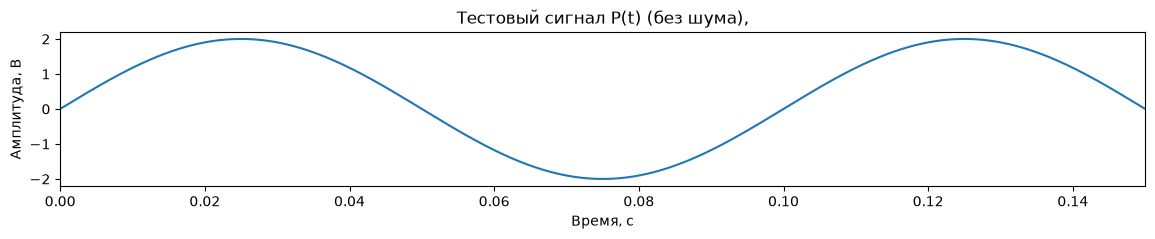

In [ ]:
values_signal = generate_signal(t, f, A)
fig, ax = plt.subplots(1,1,figsize = (14,2))
ax.plot(t, values_signal)

ax.set_xlabel("Время, с")
ax.set_ylabel("Акустическое давление, Па")
ax.set_xlim(**TIME_LIMIT)
ax.set_title("Тестовый сигнал P(t) (без шума),")
plt.show()

In [144]:
def generate_noise(scale):
    return np.random.normal(loc = 0, scale = scale, size = N)

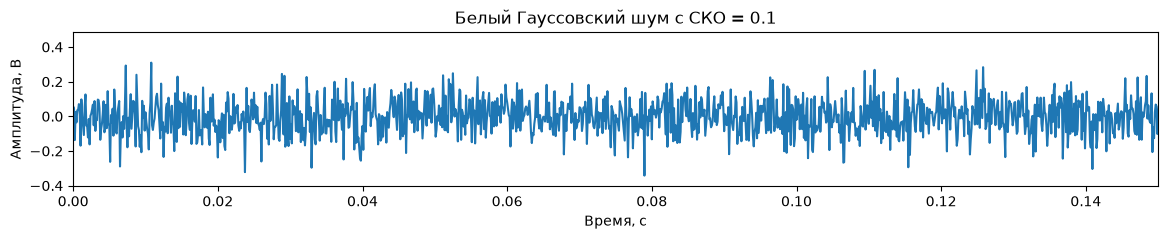

In [ ]:
# ШУМ
noise = generate_noise(sigma_noise)
fig, ax = plt.subplots(1,1,figsize = (14,2))
ax.plot(t, noise)
ax.set_xlabel("Время, с")
ax.set_ylabel("Акустическое давление, Па")
ax.set_xlim(**TIME_LIMIT)
ax.set_title(rf"Белый Гауссовский шум с СКО = {sigma_noise}")
plt.show()

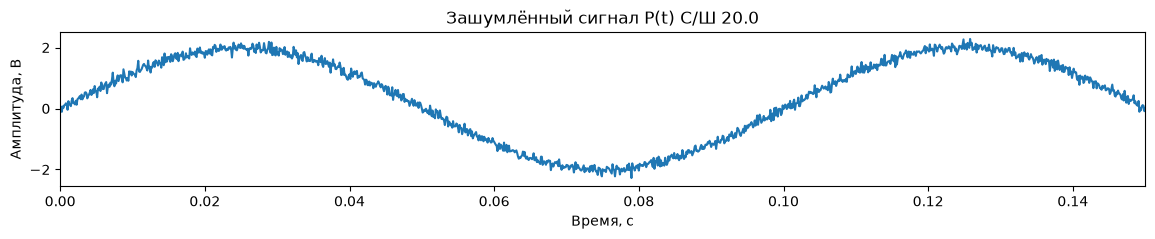

In [ ]:
noise_signal = values_signal + noise
fig, ax = plt.subplots(1,1,figsize = (14,2))
ax.plot(t, noise_signal)
ax.set_xlabel("Время, с")
ax.set_ylabel("Акустическое давление, Па")
ax.set_xlim(**TIME_LIMIT)
ax.set_title(rf"Зашумлённый сигнал P(t) C/Ш {round(A/sigma_noise,2)}")
plt.show()

C:\Users\super\AppData\Local\Temp\ipykernel_21376\1744483326.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


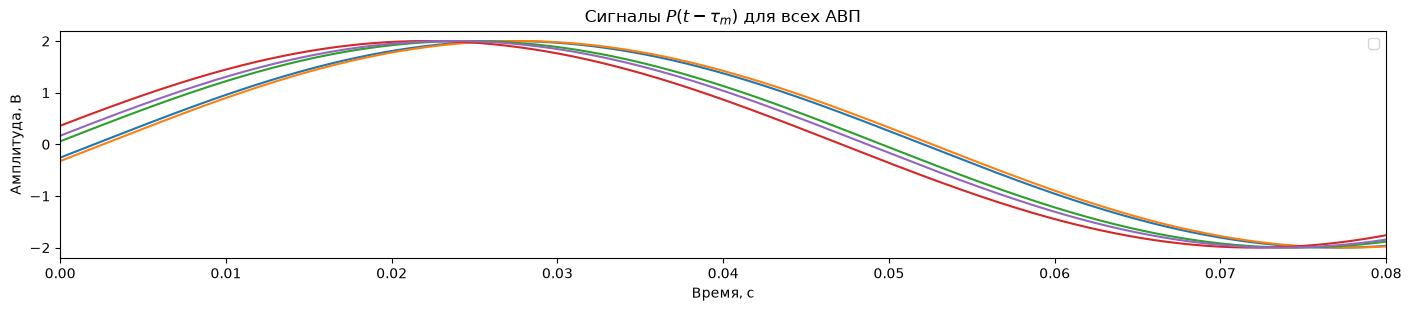

In [ ]:
tau_array = get_tau_array(M, R, phi_0) # shape (M,)
gamma_array = get_gamma_array(M)
fig, ax = plt.subplots(1,1,figsize = (14,3),constrained_layout = True)

for idx, (tau, gamma) in enumerate(zip(tau_array, gamma_array)):
    
    signal = generate_signal(t - tau, f, A)
    ax.plot(t, signal)
    ax.set_xlabel("Время, с")
    ax.set_ylabel("Акустическое давление, Па")
    ax.set_xlim(0,0.08)
    ax.set_title("Сигналы на выходе датчиков решётки с учётом временных задержек")

ax.set_title(r"Сигналы $P(t-\tau_m)$ для всех АВП")
ax.legend()

In [148]:
def compute_avp_signals(
                      p_t: np.ndarray,
                      phi_0: float,
                      noise_level: float = 0) -> dict:
    """Рассчёт y0 y1 y2 для АВП"""
    y0 = p_t + generate_noise(noise_level) # size (1 x N)
    y1 = p_t*np.cos(phi_0) + generate_noise(noise_level)
    y2 = p_t*np.sin(phi_0) + generate_noise(noise_level)
        
    return {
        "y0": y0,
        "y1": y1,
        "y2": y2
    }


In [149]:
def compute_channel_matrix(
                      t: np.ndarray, 
                      f: float,
                      phi_0: float,
                      tau_array: np.ndarray,
                      M: int,
                      N: int,
                      noise_level: float = sigma_noise,
                      A: float = 1.0) -> np.ndarray:
    """Функция возращает матрицу 3M x N со значениями для каждого из трёх каналов датчика АВП"""
    channel_matrix = np.zeros((3*M, N)) # Создаём нулевую матрицу размера M x N
    for idx, tau in enumerate(tau_array):
        p_t = generate_signal(t - tau, f, A)
        signals = compute_avp_signals(p_t, phi_0, noise_level)

    
        sensor_matrix = np.vstack((signals["y0"], signals["y1"], signals["y2"])) 
        channel_matrix[idx*3:idx*3+3] = sensor_matrix
        
    return channel_matrix

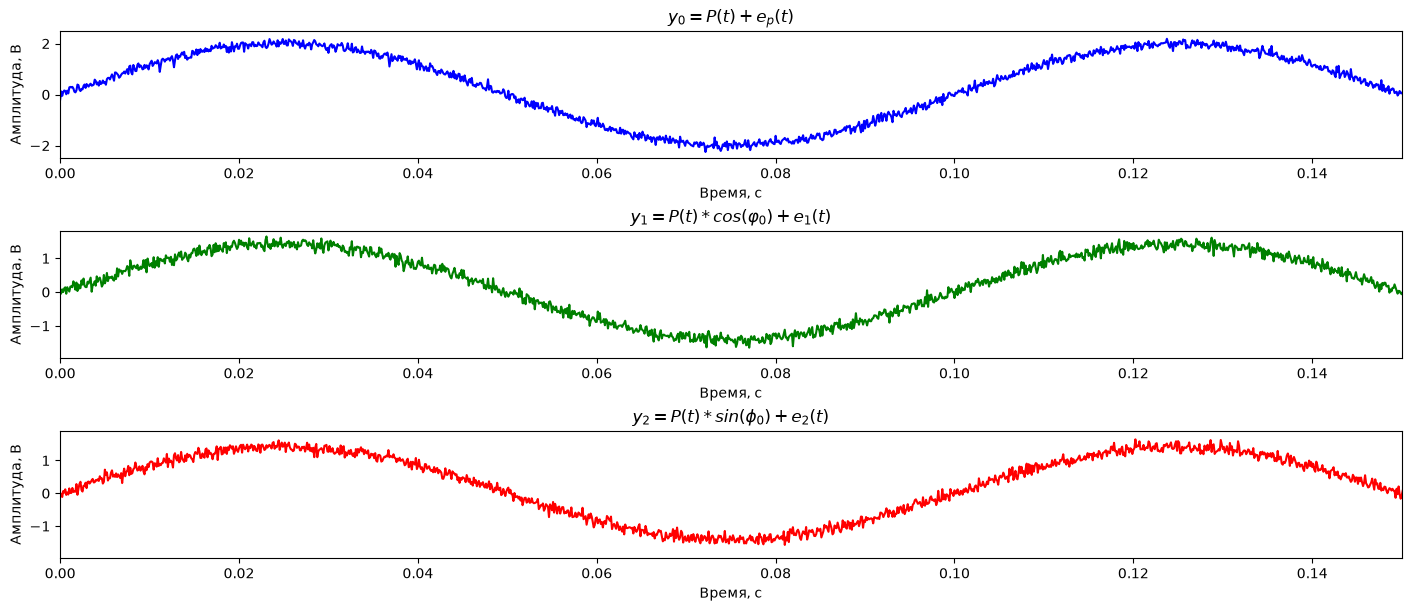

In [ ]:
p_t = generate_signal(t, f, A)
signals = compute_avp_signals(p_t, phi_0, sigma_noise)

fig, axs = plt.subplots(3,1, figsize = (14,6), constrained_layout = True)
colors = ("blue", "green", "red")
titles = (rf"$y_0 = P(t) + e_p(t)$", rf"$y_1 = P(t)*cos(\varphi_0) + e_1(t)$" , rf"$y_2 = P(t)*sin(\phi_0) + e_2(t)$" )

for idx, (y, title, color) in enumerate(zip(signals.values(),titles,colors)):
    axs[idx].plot(t,y, color = color)
    axs[idx].set_xlabel("Время, с")
    axs[idx].set_ylabel("Акустическое давление, Па")
    axs[idx].set_xlim(**TIME_LIMIT)
    axs[idx].set_title(title)
    

In [ ]:
def generate_covariation_matrix(matrix: np.ndarray,
                                N: int) -> np.ndarray:
    return (matrix @ matrix.T) / N

In [ ]:
channel_matrix = compute_channel_matrix(t, f, phi_0, tau_array, M,N) # (3M x N)
W = generate_covariation_matrix(channel_matrix, N) # 3M x 3M